# BRIGHTER Multilingual Emotion Classification with Qwen3.5

This notebook runs all experiments for our report. The core experiment fine-tunes `Qwen/Qwen3.5-0.8B` as a generative JSON classifier on English, Swahili, and Ukrainian, then evaluates it on all six BRIGHTER languages (three trained, three zero-shot). Running it end-to-end in `full` mode regenerates every table and figure we submit.

Beyond the core model, we run three supporting studies:
- **Size scaling** (Section 7): base vs. fine-tuned macro-F1 across 0.8B, 2B, 4B, 9B.
- **Chinese heritage** (Section 8): does Qwen's pretraining on Chinese help on the one CJK language in BRIGHTER?
- **Noise floor** (Section 9): 5-seed run on 0.8B to see how much variance to expect (~+-0.01 at epoch 3).

Long-running studies are cache-aware: if the output CSV already exists they skip recomputation. On a machine without a GPU, any study with no cached CSV is skipped with a warning.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT: Path = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

# Core pipeline (Tier 1: train / evaluate / explain).
from src.brighter_emotion_pipeline_qwen import EVAL_LANGUAGES
from src.brighter_emotion_pipeline_qwen import SYSTEM_PROMPT
from src.brighter_emotion_pipeline_qwen import USER_PROMPT_TEMPLATE
from src.brighter_emotion_pipeline_qwen import RunConfig
from src.brighter_emotion_pipeline_qwen import compare_base_and_finetuned
from src.brighter_emotion_pipeline_qwen import compare_base_and_finetuned_per_label
from src.brighter_emotion_pipeline_qwen import create_train_internal_dev_split
from src.brighter_emotion_pipeline_qwen import create_smoke_train_internal_dev_split
from src.brighter_emotion_pipeline_qwen import create_trainer
from src.brighter_emotion_pipeline_qwen import describe_training_data
from src.brighter_emotion_pipeline_qwen import ensure_directories
from src.brighter_emotion_pipeline_qwen import evaluate_base_model_languages
from src.brighter_emotion_pipeline_qwen import evaluate_dataset
from src.brighter_emotion_pipeline_qwen import evaluate_languages
from src.brighter_emotion_pipeline_qwen import explain_lime_examples
from src.brighter_emotion_pipeline_qwen import load_model
from src.brighter_emotion_pipeline_qwen import load_tokenizer
from src.brighter_emotion_pipeline_qwen import plot_macro_f1_by_language
from src.brighter_emotion_pipeline_qwen import plot_macro_f1_improvement_by_language
from src.brighter_emotion_pipeline_qwen import plot_per_label_f1_by_language
from src.brighter_emotion_pipeline_qwen import plot_per_label_f1_improvement
from src.brighter_emotion_pipeline_qwen import select_lime_examples
from src.brighter_emotion_pipeline_qwen import set_random_seed
from src.brighter_emotion_pipeline_qwen import tokenize_dataset
from src.brighter_emotion_pipeline_qwen import write_markdown_summary

# Report-wide studies + inline figure display.
from src.brighter_emotion_pipeline_qwen import cuda_is_available
from src.brighter_emotion_pipeline_qwen import show_figure
from src.brighter_emotion_pipeline_qwen import study_scaling_base
from src.brighter_emotion_pipeline_qwen import study_scaling_finetune
from src.brighter_emotion_pipeline_qwen import study_all_languages_base
from src.brighter_emotion_pipeline_qwen import study_chinese
from src.brighter_emotion_pipeline_qwen import study_multiseed
from src.brighter_emotion_pipeline_qwen import plot_scaling_curve
from src.brighter_emotion_pipeline_qwen import plot_language_size_heatmap
from src.brighter_emotion_pipeline_qwen import plot_chinese_base_vs_finetuned
from src.brighter_emotion_pipeline_qwen import plot_multiseed_bands

print(f"CUDA available (heavy studies will recompute if no cached CSV): {cuda_is_available()}")

CUDA available (heavy studies will recompute if no cached CSV): True


## Step 1: Configure Run and Inspect Prompt

The fine-tuning prompt shows the target emotion labels and asks for strict JSON output. We use the same format at inference.

Set `RUN_MODE`:
- `"smoke"` - 2-step sanity check on a tiny sample; macro-F1 will be near zero, but it confirms the pipeline runs end-to-end.
- `"lite"` - 80 training examples per language, 3 epochs, eval capped at 150 per language. Gives real (non-trivial) numbers in ~15-20 min on Apple MPS.
- `"full"` - full train split, full official dev evaluation; these are the numbers in the report.

Train and eval subsets use a seeded shuffle (not a head slice) so rare emotions stay represented at small sample sizes.

`studies_config` (used in Sections 7-9) always loads from committed CSVs, so the scaling and noise-floor numbers are independent of `RUN_MODE`.

In [2]:
RUN_MODE: str = "full"  # "smoke" (2-step backend check) | "lite" (bounded real run) | "full" (final numbers)

if RUN_MODE == "smoke":
    config: RunConfig = RunConfig(
        output_dir=PROJECT_ROOT / "outputs",
        reports_dir=PROJECT_ROOT / "reports",
        run_suffix="smoke",
        max_length=128,
        max_new_tokens=16,
        max_steps=2,
        num_train_epochs=1,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=1,
        lime_num_samples=4,
    )
elif RUN_MODE == "lite":
    config = RunConfig(
        output_dir=PROJECT_ROOT / "outputs",
        reports_dir=PROJECT_ROOT / "reports",
        run_suffix="lite",
        max_length=256,
        max_new_tokens=24,
        num_train_epochs=3,
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        gradient_checkpointing=False,
        max_eval_examples_per_language=150,
        smoke_train_examples_per_language=80,
        smoke_internal_dev_examples_per_language=20,
    )
else:
    config = RunConfig(
        output_dir=PROJECT_ROOT / "outputs",
        reports_dir=PROJECT_ROOT / "reports",
        # Tuned on internal-dev. The LR / epoch / weight-decay sweeps converged on lr=1e-5 (default),
        # 3 epochs, wd=0.01 (default): lower/higher LR and higher weight decay all landed within the
        # ~0.01 run-to-run noise floor. Only epochs (2 -> 3) and the cosine+warmup schedule changed.
        num_train_epochs=3,
        # Throughput: with GPU memory to spare, train on a real per-device batch and drop gradient
        # checkpointing. Effective batch stays 16 (4 x 4), unchanged from the old 1 x 16.
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=4,
        gradient_checkpointing=False,
    )

# Fixed config for the report-wide studies (Sections 7-9). run_suffix="" so the canonical,
# mode-independent caches are hit (the multiseed CSV is prefixed by this config's artifact_prefix).
studies_config: RunConfig = RunConfig(
    output_dir=PROJECT_ROOT / "outputs",
    reports_dir=PROJECT_ROOT / "reports",
)

# "smoke" and "lite" train on a small subsampled split; only "smoke" stops at the tiny internal-dev sample.
USE_SUBSAMPLED_SPLIT: bool = RUN_MODE in ("smoke", "lite")
EVALUATE_INTERNAL_DEV_ONLY: bool = RUN_MODE == "smoke"

set_random_seed(seed=config.seed)
ensure_directories(config=config)
ensure_directories(config=studies_config)

print(f"Model: {config.model_name}")
print(f"Run mode: {RUN_MODE}")
print(f"Artifact prefix: {config.artifact_prefix}")
print(f"Studies artifact prefix: {studies_config.artifact_prefix}")
print("System prompt:")
print(SYSTEM_PROMPT)
print("User prompt template:")
print(USER_PROMPT_TEMPLATE)

Model: Qwen/Qwen3.5-0.8B
Run mode: full
Artifact prefix: qwen3.5-0.8B_
Studies artifact prefix: qwen3.5-0.8B_
System prompt:
You are an expert BRIGHTER emotion annotation model. Classify the text with any of these emotions: anger, disgust, fear, joy, sadness, surprise. Return only valid JSON with this schema: {"emotions": ["label"]}. Use an empty list when none of the listed emotions are present.
User prompt template:
Language: {language_name}
Text: {text}
Emotions JSON:


## Step 2: Prepare Data and Inspect Training Distribution

Only the official train split is loaded here. The official dev split is not touched until Section 4.

In [3]:
tokenizer = load_tokenizer(config=config)
if USE_SUBSAMPLED_SPLIT:
    splits = create_smoke_train_internal_dev_split(config=config)
else:
    splits = create_train_internal_dev_split(config=config)
overview_frame: pd.DataFrame = describe_training_data(config=config)
overview_frame

,language,language_name,rows,anger_positive_rate,disgust_positive_rate,fear_positive_rate,joy_positive_rate,sadness_positive_rate,surprise_positive_rate
0,eng,English,2764,0.120478,0.000000,0.582489,0.243849,0.316932,0.303546
1,swa,Swahili,3307,0.094043,0.071969,0.028122,0.133958,0.105836,0.162080
2,ukr,Ukrainian,2466,0.039740,0.034874,0.069749,0.167072,0.135036,0.079481


Sanity check: all three training languages (eng, swa, ukr) should appear and label frequencies should look plausible. Open `reports/tables/qwen3.5-0.8B_training_data_overview.csv` to verify.

## Step 3: Train on Internal Train, Validate on Internal Dev

We mask the loss to the JSON completion tokens only, not the prompt. After training, internal-dev macro-F1 is computed with generation and JSON parsing.

In [4]:
model = load_model(config=config)
tokenized_train_dataset = tokenize_dataset(dataset=splits["train"], tokenizer=tokenizer, config=config)
tokenized_internal_dev_dataset = tokenize_dataset(dataset=splits["internal_dev"], tokenizer=tokenizer, config=config)
trainer = create_trainer(
    model=model,
    tokenizer=tokenizer,
    tokenized_train_dataset=tokenized_train_dataset,
    tokenized_internal_dev_dataset=tokenized_internal_dev_dataset,
    config=config,
)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [5]:
trainer.train()
trainer.save_model(str(config.model_dir))
tokenizer.save_pretrained(config.model_dir)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


Epoch,Training Loss,Validation Loss
1,0.177030,0.169154
2,0.137800,0.162443
3,0.100712,0.172935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.embed_tokens.weight', 'model.layers.0.linear_attn.dt_bias', 'model.layers.0.linear_attn.A_log', 'model.layers.0.linear_attn.conv1d.weight', 'model.layers.0.linear_attn.norm.weight', 'model.layers.0.linear_attn.out_proj.weight', 'model.layers.0.linear_attn.in_proj_qkv.weight', 'model.layers.0.linear_attn.in_proj_z.weight', 'model.layers.0.linear_attn.in_proj_b.weight', 'model.layers.0.linear_attn.in_proj_a.weight', 'model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight', 'model.layers.0.mlp.down_proj.weight', 'model.layers.0.input_layernorm.weight', 'model.layers.0.post_attention_layernorm.weight', 'model.layers.1.linear_attn.dt_bias', 'model.layers.1.linear_attn.A_log', 'model.layers.1.linear_attn.conv1d.weight', 'model.layers.1.linear_attn.norm.weight', 'model.layers.1.linear_attn.out_proj.weight', 'model.layers.1.linear_attn.in_proj_qkv.weight', 'model.layers.1.linear_attn.in_proj_z.weig

[transformers] There were unexpected keys in the checkpoint model loaded: ['model.language_model.embed_tokens.weight', 'model.language_model.layers.0.input_layernorm.weight', 'model.language_model.layers.0.linear_attn.A_log', 'model.language_model.layers.0.linear_attn.conv1d.weight', 'model.language_model.layers.0.linear_attn.dt_bias', 'model.language_model.layers.0.linear_attn.in_proj_a.weight', 'model.language_model.layers.0.linear_attn.in_proj_b.weight', 'model.language_model.layers.0.linear_attn.in_proj_qkv.weight', 'model.language_model.layers.0.linear_attn.in_proj_z.weight', 'model.language_model.layers.0.linear_attn.norm.weight', 'model.language_model.layers.0.linear_attn.out_proj.weight', 'model.language_model.layers.0.mlp.down_proj.weight', 'model.language_model.layers.0.mlp.gate_proj.weight', 'model.language_model.layers.0.mlp.up_proj.weight', 'model.language_model.layers.0.post_attention_layernorm.weight', 'model.language_model.layers.1.input_layernorm.weight', 'model.langua

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/home/nik/code/github.com/MayNiklas/MMD2-project/outputs/qwen3.5-0.8B_model/tokenizer_config.json',
 '/home/nik/code/github.com/MayNiklas/MMD2-project/outputs/qwen3.5-0.8B_model/chat_template.jinja',
 '/home/nik/code/github.com/MayNiklas/MMD2-project/outputs/qwen3.5-0.8B_model/tokenizer.json')

In [6]:
internal_dev_metrics_frame, internal_dev_per_label_frame, internal_dev_predictions_frame = evaluate_dataset(
    model=trainer.model,
    tokenizer=tokenizer,
    dataset=splits["internal_dev"],
    split="internal_dev",
    config=config,
)
internal_dev_metrics_frame[["language_name", "training_status", "macro_f1", "micro_f1", "samples_f1"]]

,language_name,training_status,macro_f1,micro_f1,samples_f1
0,Swahili,trained,0.306995,0.349153,0.200673
1,English,trained,0.578798,0.740511,0.670482
2,Ukrainian,trained,0.522428,0.599407,0.262713


Check that the internal-dev macro-F1 at epoch 3 looks non-trivial. The fine-tuned model is saved to `outputs/qwen3.5-0.8B_model`.

## Step 4: Final Evaluation on Official Dev

Evaluates on the official dev split across all six languages: eng/swa/ukr (trained) and deu/ptbr/yor (zero-shot).
In `smoke` mode this runs on the small internal-dev sample instead.

In [7]:
if EVALUATE_INTERNAL_DEV_ONLY:
    metrics_frame, per_label_metrics_frame, predictions_frame = evaluate_dataset(
        model=trainer.model,
        tokenizer=tokenizer,
        dataset=splits["internal_dev"],
        split="smoke_internal_dev",
        config=config,
    )
else:
    metrics_frame, per_label_metrics_frame, predictions_frame = evaluate_languages(
        model=trainer.model,
        tokenizer=tokenizer,
        languages=EVAL_LANGUAGES,
        split="dev",
        config=config,
    )
metrics_frame[["language_name", "training_status", "macro_f1", "micro_f1", "samples_f1"]]

,language_name,training_status,macro_f1,micro_f1,samples_f1
0,English,trained,0.600109,0.729805,0.642816
1,Swahili,trained,0.273313,0.337942,0.191773
2,Ukrainian,trained,0.500578,0.542240,0.269411
3,German,zero-shot,0.390547,0.417582,0.265000
4,Brazilian Portuguese,zero-shot,0.395578,0.539877,0.385000
5,Yoruba,zero-shot,0.096957,0.110236,0.037156


In [8]:
# Per-label F1 (required deliverable): one row per language x emotion.
per_label_metrics_frame

,language,language_name,split,training_status,label,f1
0,eng,English,dev,trained,anger,0.689655
1,eng,English,dev,trained,disgust,0.000000
2,eng,English,dev,trained,fear,0.747253
3,eng,English,dev,trained,joy,0.690909
4,eng,English,dev,trained,sadness,0.763158
5,eng,English,dev,trained,surprise,0.709677
6,swa,Swahili,dev,trained,anger,0.211538
7,swa,Swahili,dev,trained,disgust,0.208000
8,swa,Swahili,dev,trained,fear,0.100000
9,swa,Swahili,dev,trained,joy,0.509589


## Step 5: Base Model vs. Fine-Tuned

We run the same evaluation on the untrained base model to isolate the fine-tuning contribution. `macro_f1_delta` = fine-tuned minus base; positive means fine-tuning helped for that language.

The base model is loaded alongside the fine-tuned model temporarily, then freed after evaluation.

In [9]:
if EVALUATE_INTERNAL_DEV_ONLY:
    comparison_frame = None
    per_label_comparison_frame = None
else:
    base_model = load_model(config=config)
    base_model.to(trainer.model.device)
    base_metrics_frame, base_per_label_metrics_frame, base_predictions_frame = evaluate_base_model_languages(
        model=base_model,
        tokenizer=tokenizer,
        languages=EVAL_LANGUAGES,
        split="dev",
        config=config,
    )
    del base_model
    comparison_frame = compare_base_and_finetuned(
        finetuned_metrics_frame=metrics_frame,
        base_metrics_frame=base_metrics_frame,
        config=config,
    )
    per_label_comparison_frame = compare_base_and_finetuned_per_label(
        finetuned_per_label_frame=per_label_metrics_frame,
        base_per_label_frame=base_per_label_metrics_frame,
        config=config,
    )
comparison_frame

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

,language,language_name,training_status,macro_f1_finetuned,macro_f1_base,macro_f1_delta
0,eng,English,trained,0.600109,0.281209,0.318900
1,swa,Swahili,trained,0.273313,0.172832,0.100482
2,ukr,Ukrainian,trained,0.500578,0.295876,0.204701
3,deu,German,zero-shot,0.390547,0.301241,0.089306
4,ptbr,Brazilian Portuguese,zero-shot,0.395578,0.186373,0.209204
5,yor,Yoruba,zero-shot,0.096957,0.043416,0.053542


In [10]:
# Per-label base-vs-fine-tuned F1. f1_delta is fine-tuned minus base (positive = FT improved it).
per_label_comparison_frame

,language,language_name,training_status,label,f1_finetuned,f1_base,f1_delta
0,eng,English,trained,anger,0.689655,0.454545,0.235110
1,eng,English,trained,disgust,0.000000,0.000000,0.000000
2,eng,English,trained,fear,0.747253,0.062500,0.684753
3,eng,English,trained,joy,0.690909,0.476190,0.214719
4,eng,English,trained,sadness,0.763158,0.205128,0.558030
5,eng,English,trained,surprise,0.709677,0.488889,0.220789
6,swa,Swahili,trained,anger,0.211538,0.119658,0.091880
7,swa,Swahili,trained,disgust,0.208000,0.181070,0.026930
8,swa,Swahili,trained,fear,0.100000,0.000000,0.100000
9,swa,Swahili,trained,joy,0.509589,0.376812,0.132777


Compare trained-language rows against zero-shot rows. Full results in `reports/tables/qwen3.5-0.8B_dev_language_metrics.csv` and `reports/tables/qwen3.5-0.8B_dev_per_label_metrics.csv`.

## Step 6: Core Figures

Plots are saved as PNGs under `reports/figures/` and displayed inline.

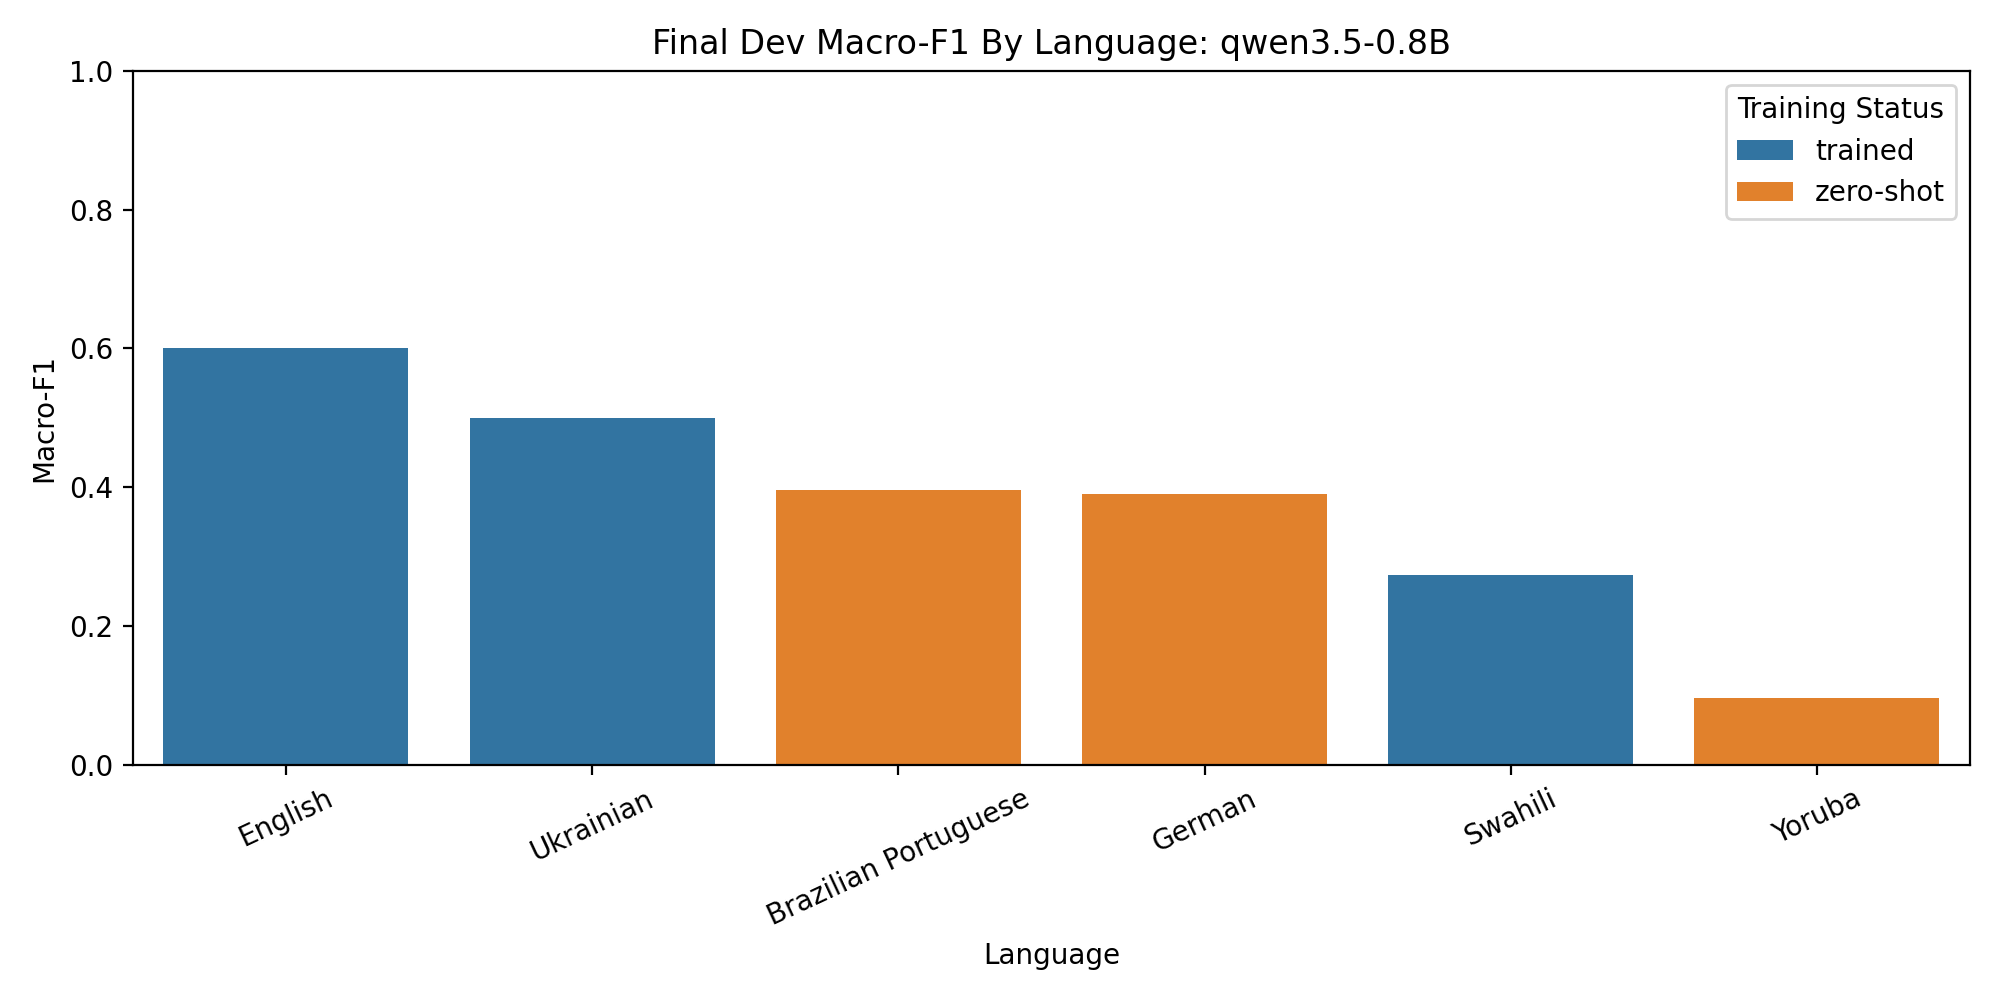

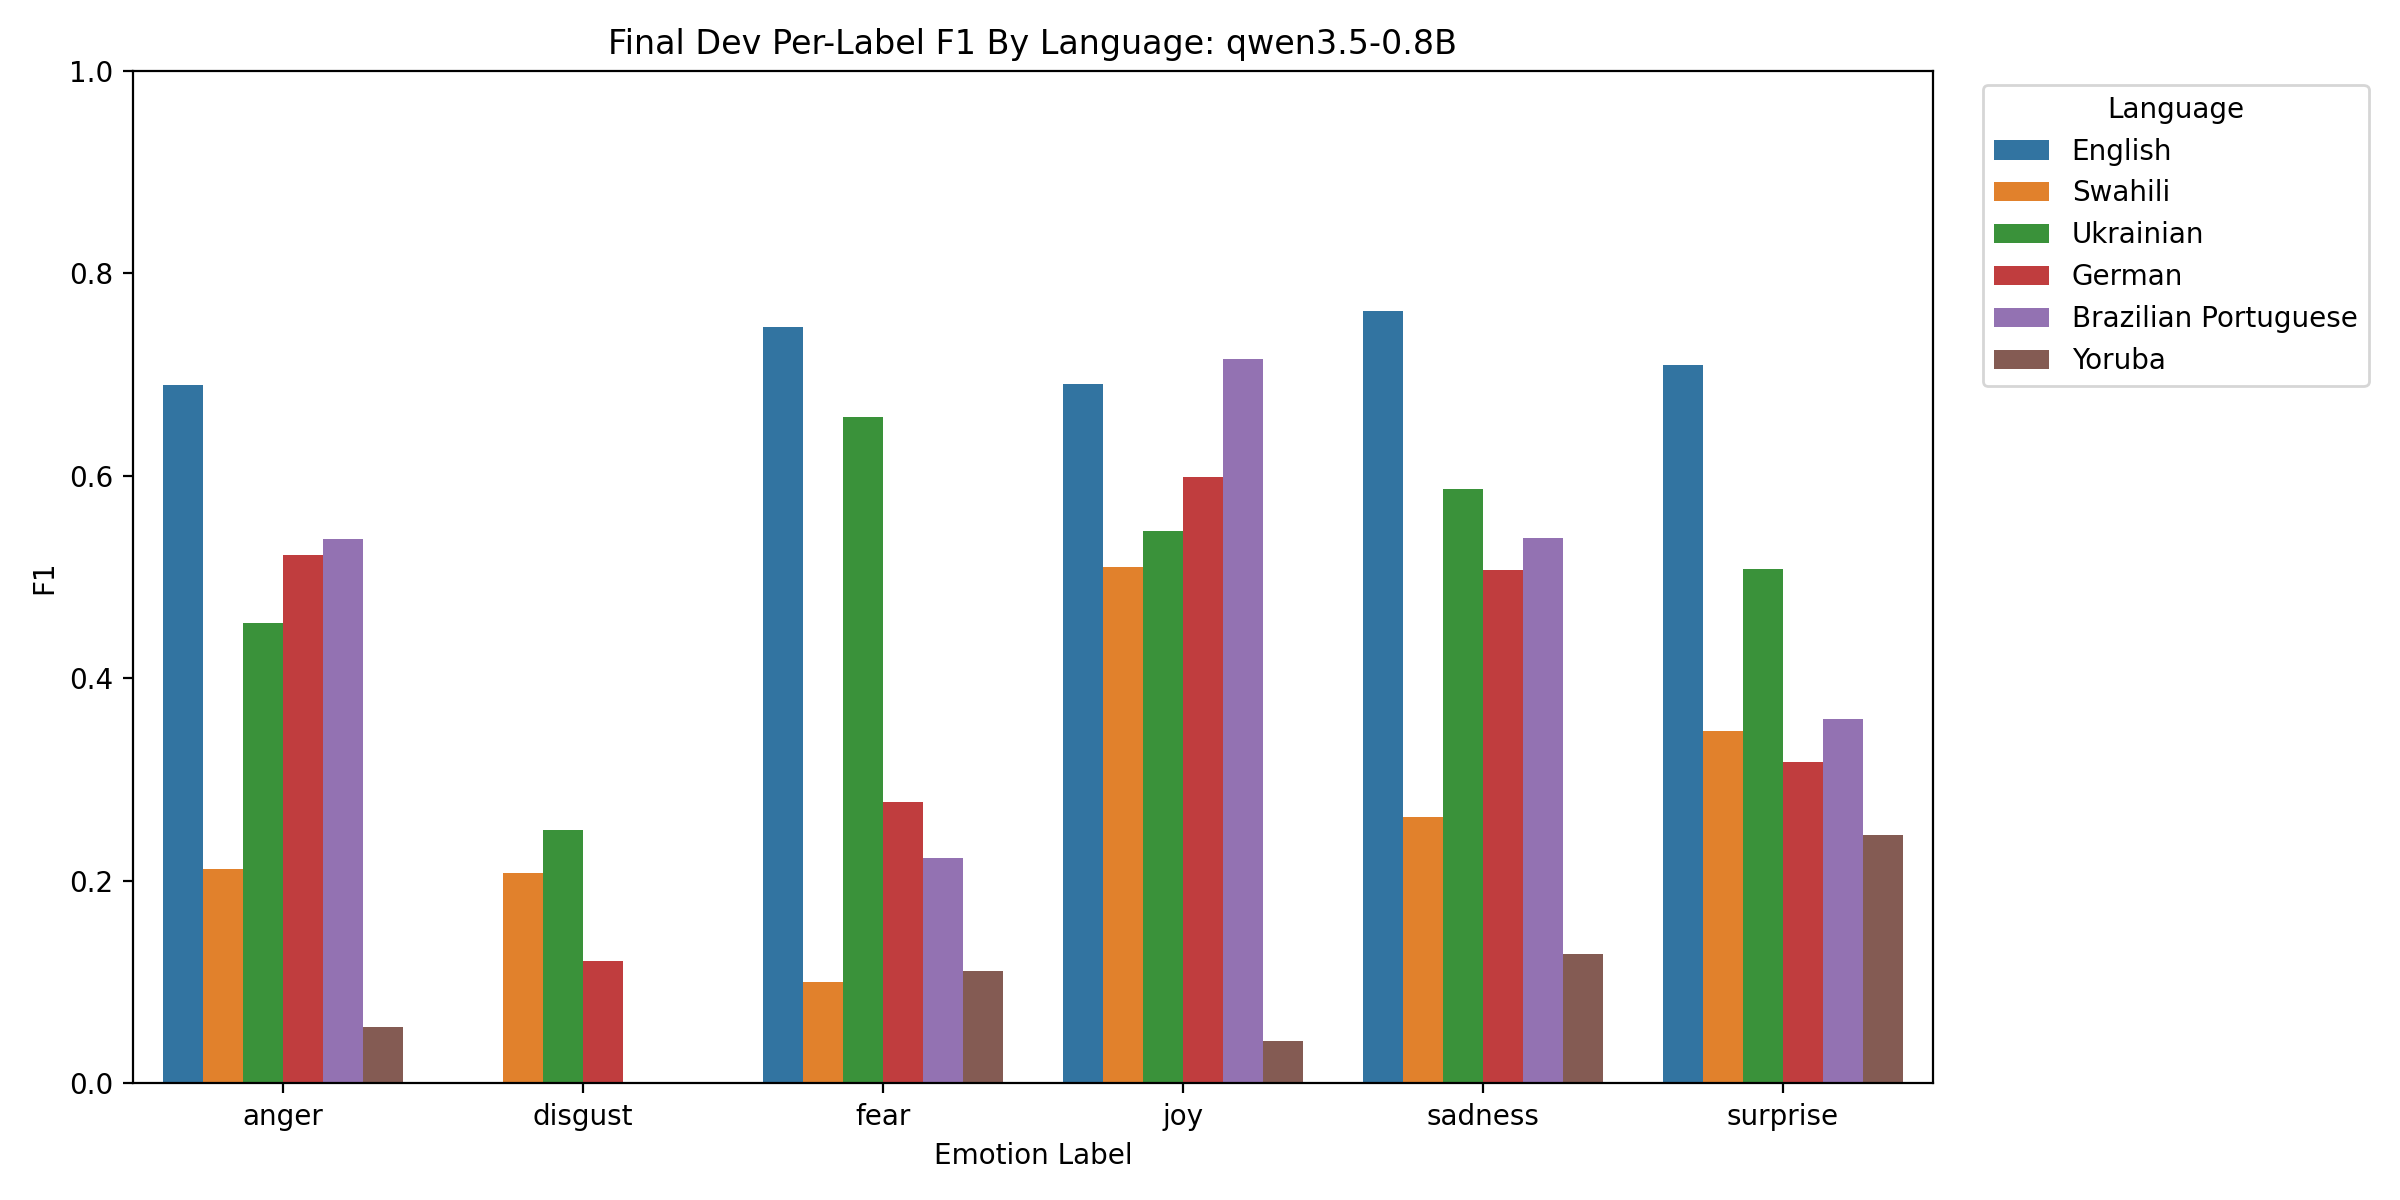

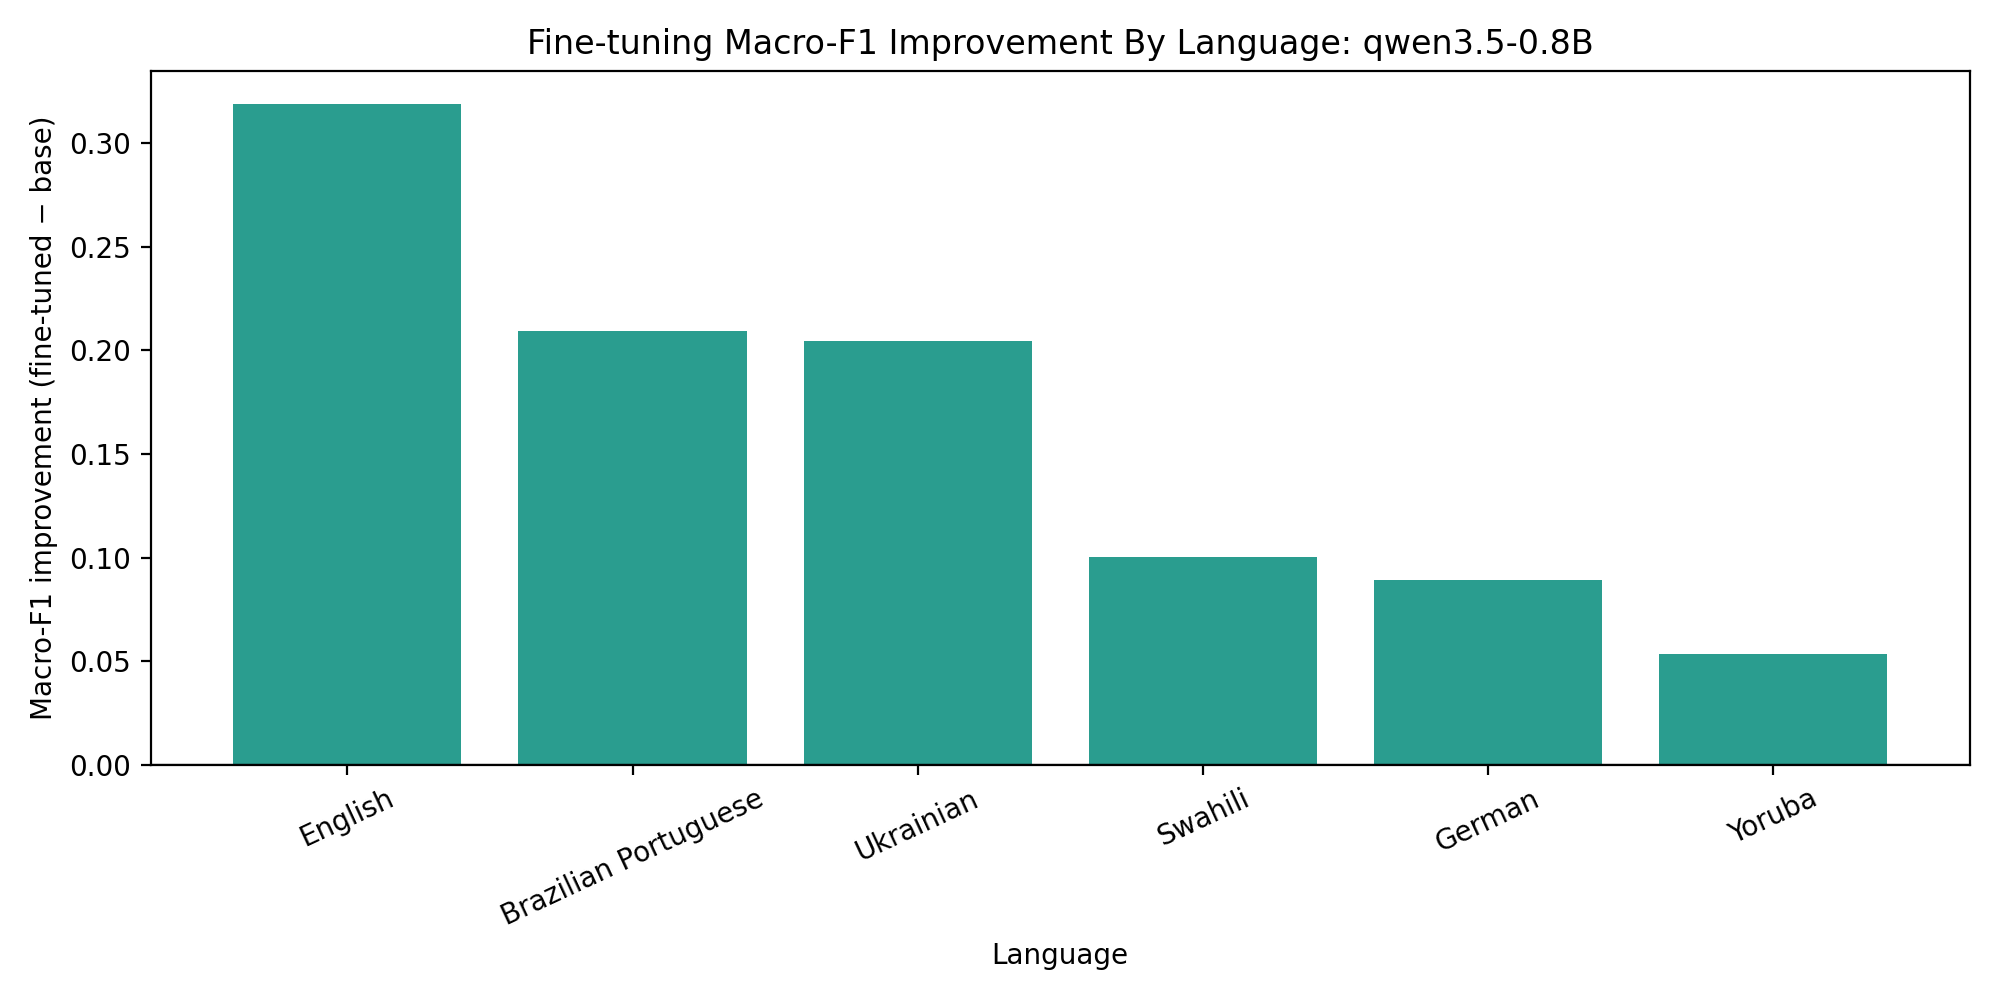

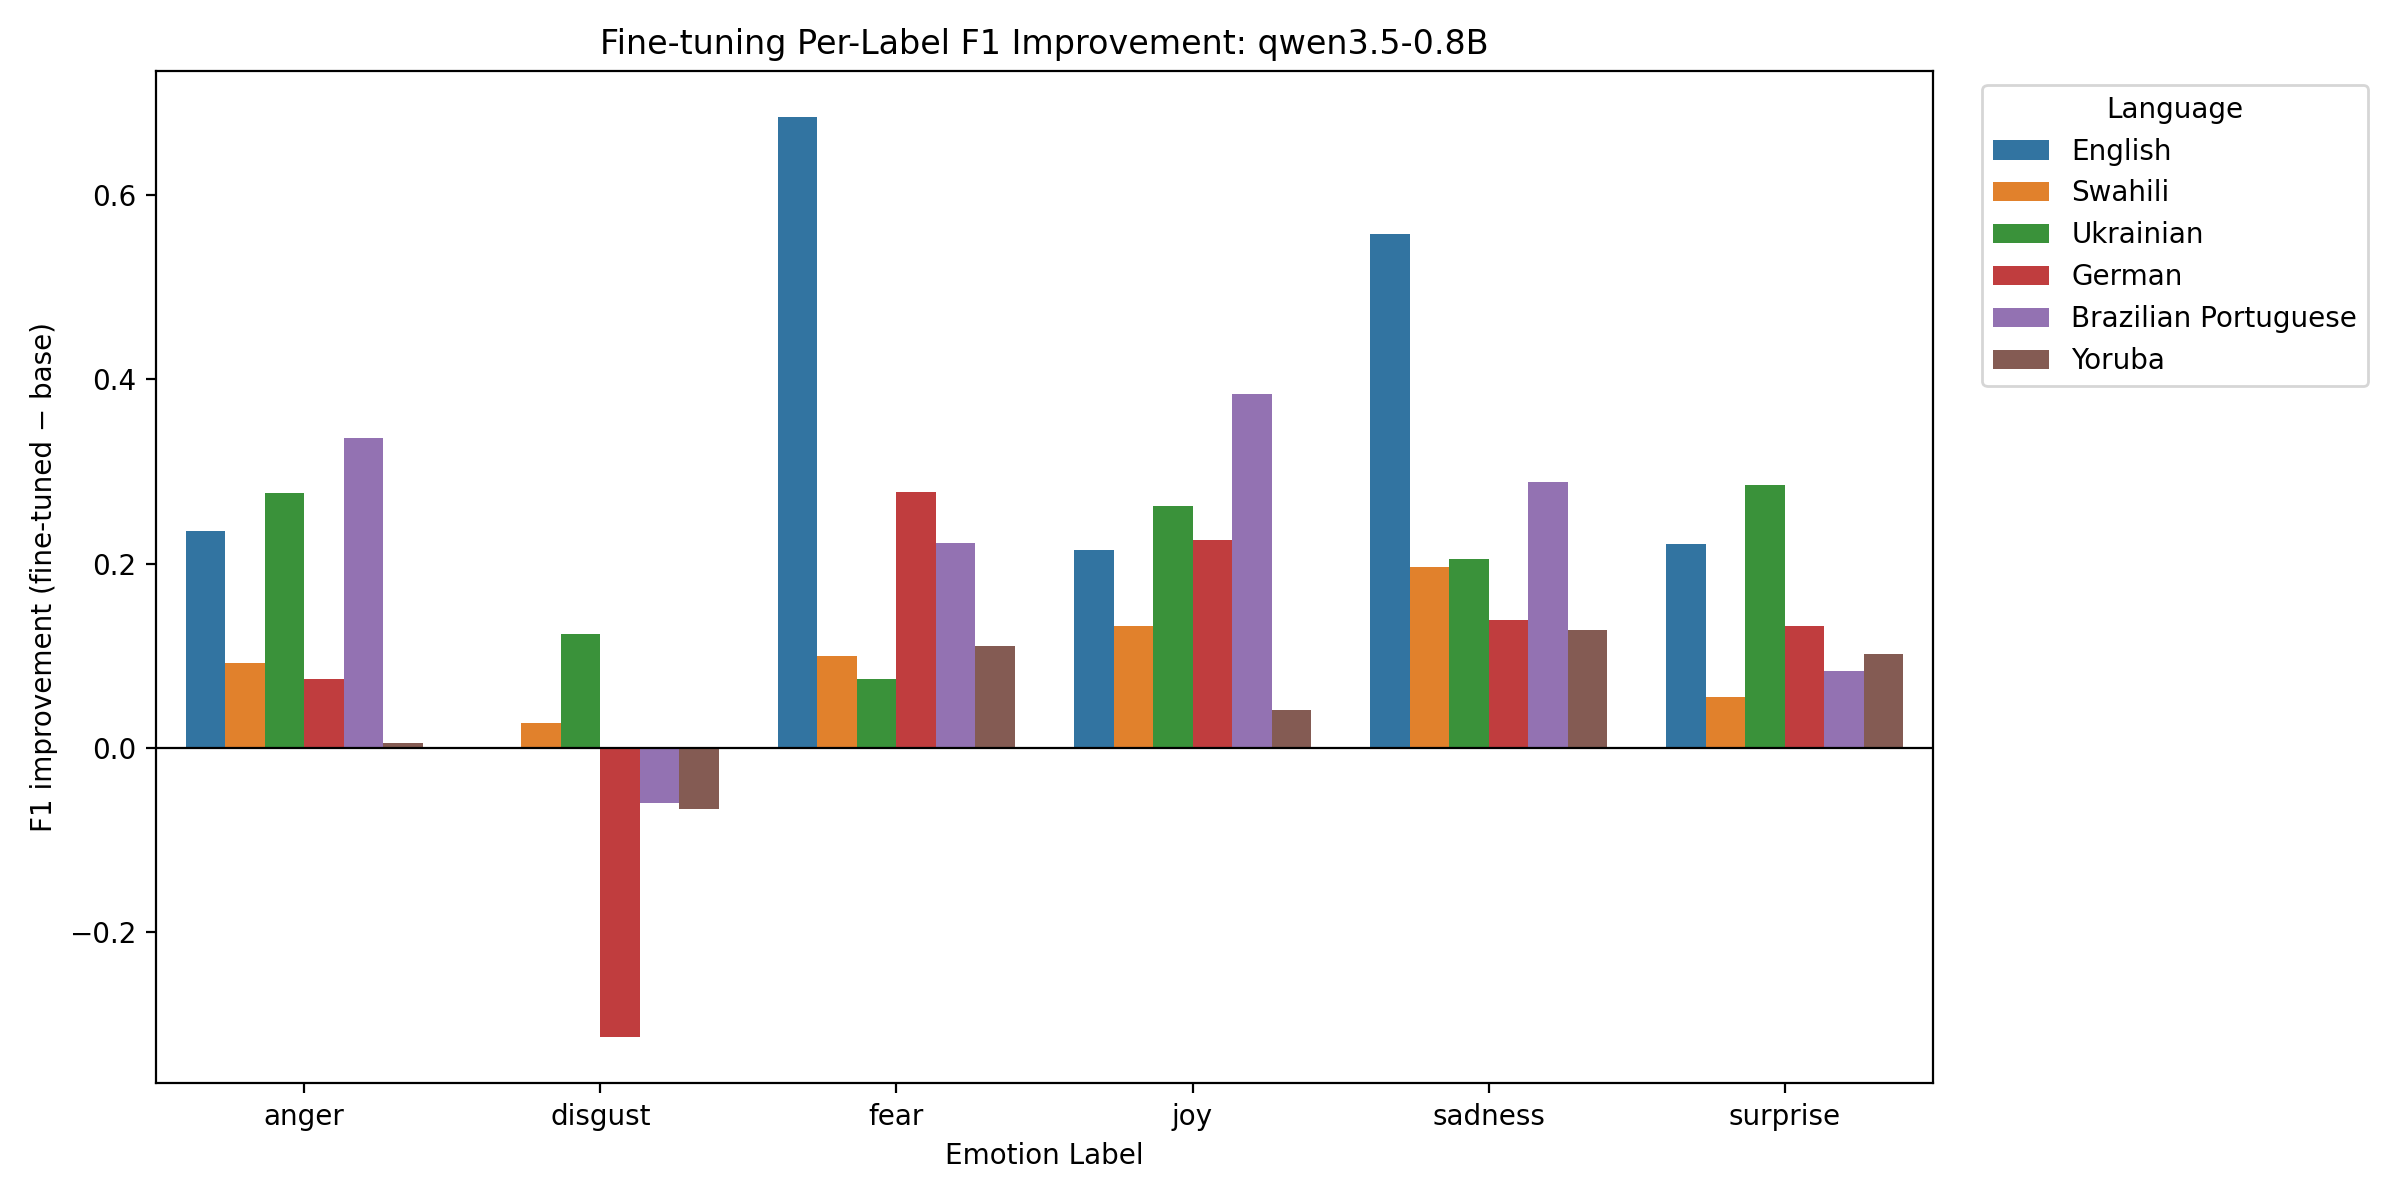

In [11]:
macro_f1_path: Path = plot_macro_f1_by_language(metrics_frame=metrics_frame, config=config)
per_label_f1_path: Path = plot_per_label_f1_by_language(
    per_label_metrics_frame=per_label_metrics_frame,
    config=config,
)
generated_figure_paths: list[Path] = [macro_f1_path, per_label_f1_path]

# Improvement plots against the base model (lite/full only; the base comparison is skipped in smoke).
if comparison_frame is not None and per_label_comparison_frame is not None:
    macro_f1_improvement_path: Path = plot_macro_f1_improvement_by_language(
        comparison_frame=comparison_frame,
        config=config,
    )
    per_label_f1_improvement_path: Path = plot_per_label_f1_improvement(
        per_label_comparison_frame=per_label_comparison_frame,
        config=config,
    )
    generated_figure_paths.extend([macro_f1_improvement_path, per_label_f1_improvement_path])

for figure_path in generated_figure_paths:
    show_figure(figure_path)

## Step 7: Size Scaling Study

We compare base (zero-shot) and fine-tuned macro-F1 across 0.8B, 2B, 4B, and 9B. Fine-tuning the 9B model is infeasible on 24 GB, so we only evaluate it as a base model.

Main finding: going from 0.8B to 4B base raises macro-F1 more than fine-tuning does. At larger sizes, fine-tuning actually hurts zero-shot transfer - the base model already understands the emotion task well enough that specializing it toward the three training languages costs more than it gains.

[scaling-base] loading cached result: /home/nik/code/github.com/MayNiklas/MMD2-project/reports/tables/qwen3.5_scaling_base_dev.csv


[scaling-finetune] loading cached result: /home/nik/code/github.com/MayNiklas/MMD2-project/reports/tables/qwen3.5_scaling_finetuned_dev.csv


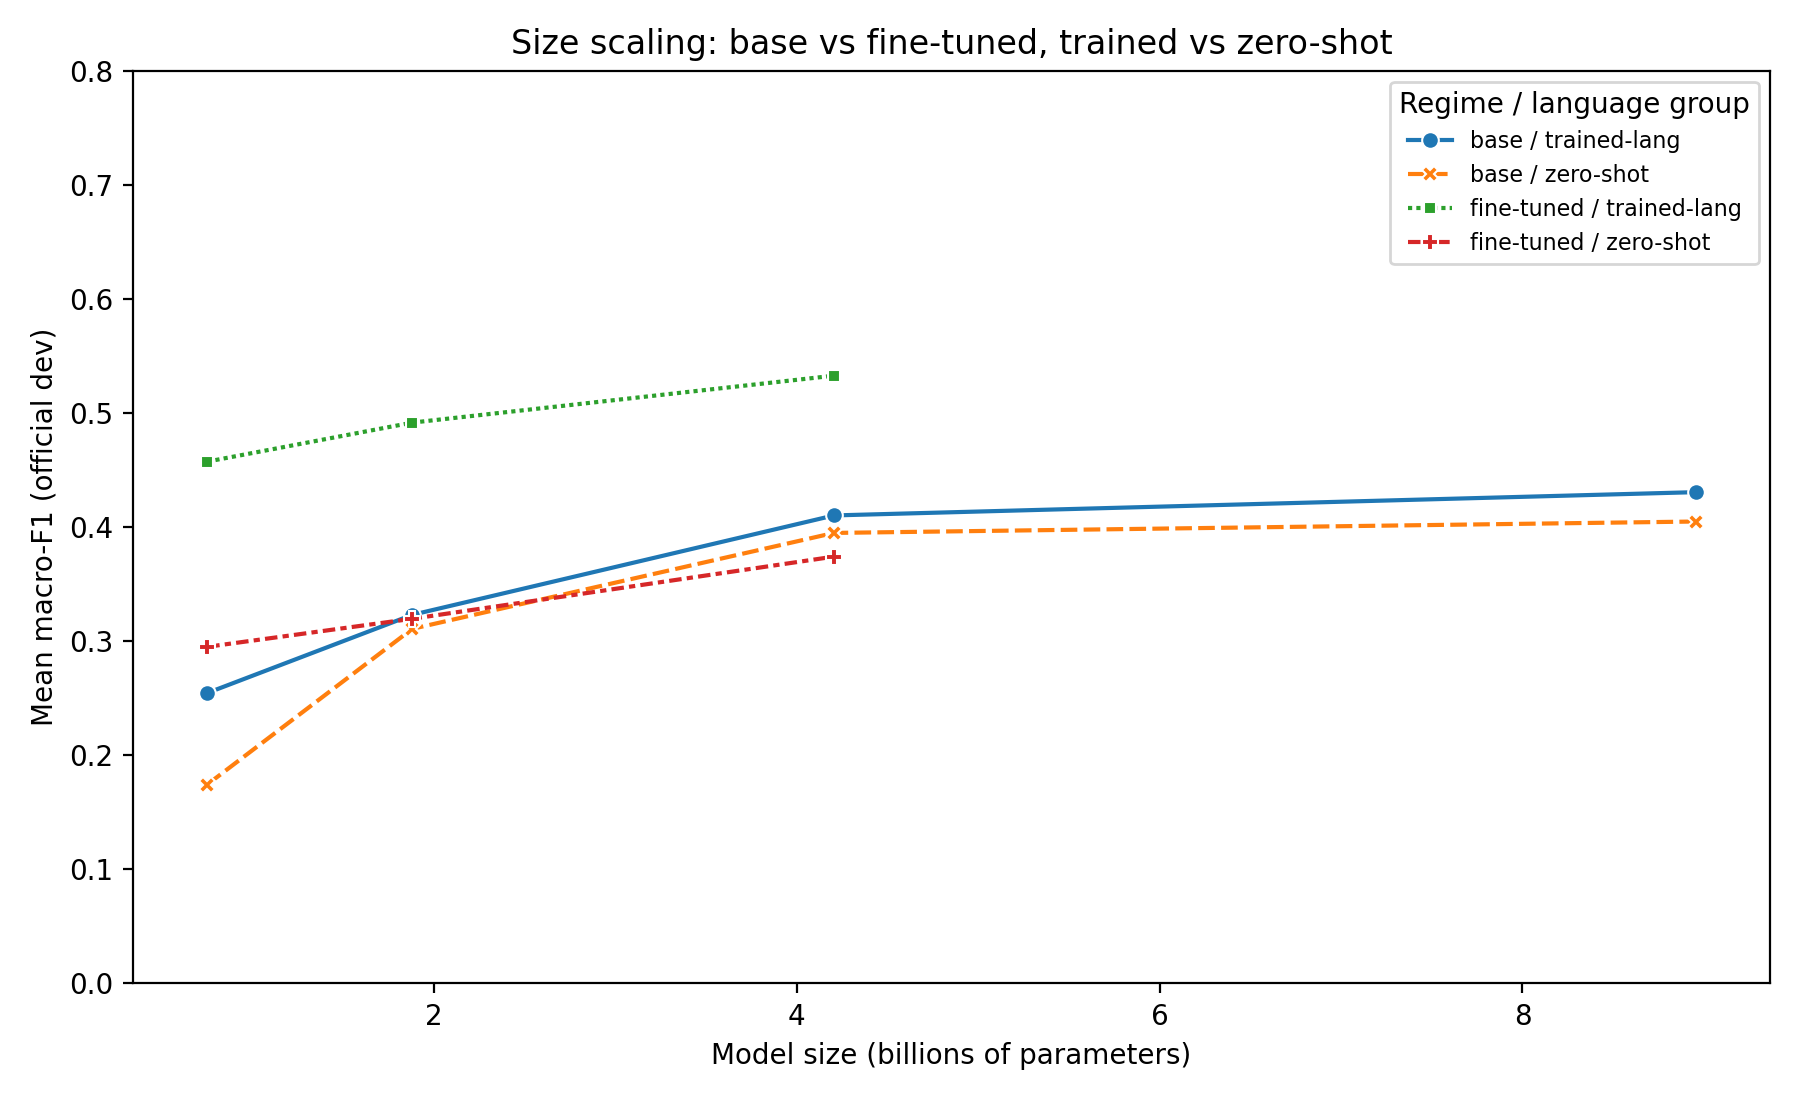

Base zero-shot mean macro-F1 by size / training status:


,params_billion,training_status,macro_f1
0,0.752,trained-lang,0.254560
1,0.752,zero-shot,0.174326
2,1.882,trained-lang,0.323068
3,1.882,zero-shot,0.310787
4,4.206,trained-lang,0.410184
5,4.206,zero-shot,0.394853
6,8.954,trained-lang,0.430591
7,8.954,zero-shot,0.404846


In [12]:
scaling_base_frame = study_scaling_base(base_config=studies_config)
scaling_finetuned_frame = study_scaling_finetune(base_config=studies_config)

if scaling_base_frame is not None:
    scaling_curve_path = plot_scaling_curve(
        base_frame=scaling_base_frame,
        finetuned_frame=scaling_finetuned_frame,
        config=studies_config,
    )
    show_figure(scaling_curve_path)
    display_cols = ["model", "params_billion", "language_name", "training_status", "macro_f1"]
    scaling_size_means = (
        scaling_base_frame.groupby(["params_billion", "training_status"], as_index=False)["macro_f1"].mean()
    )
    print("Base zero-shot mean macro-F1 by size / training status:")
    display(scaling_size_means)

### 28-language x 4-size Base Heatmap

Shows where each language lands as model size grows. Languages are sorted by their 9B score. High-resource languages (Cyrillic, Devanagari, Latin) cluster at the top; low-resource African languages sit at the bottom. Chinese lands mid-pack - pretraining coverage helps, but overall resource level matters more.

[all-languages-base] loading cached result: /home/nik/code/github.com/MayNiklas/MMD2-project/reports/tables/qwen3.5_all_languages_base_dev.csv


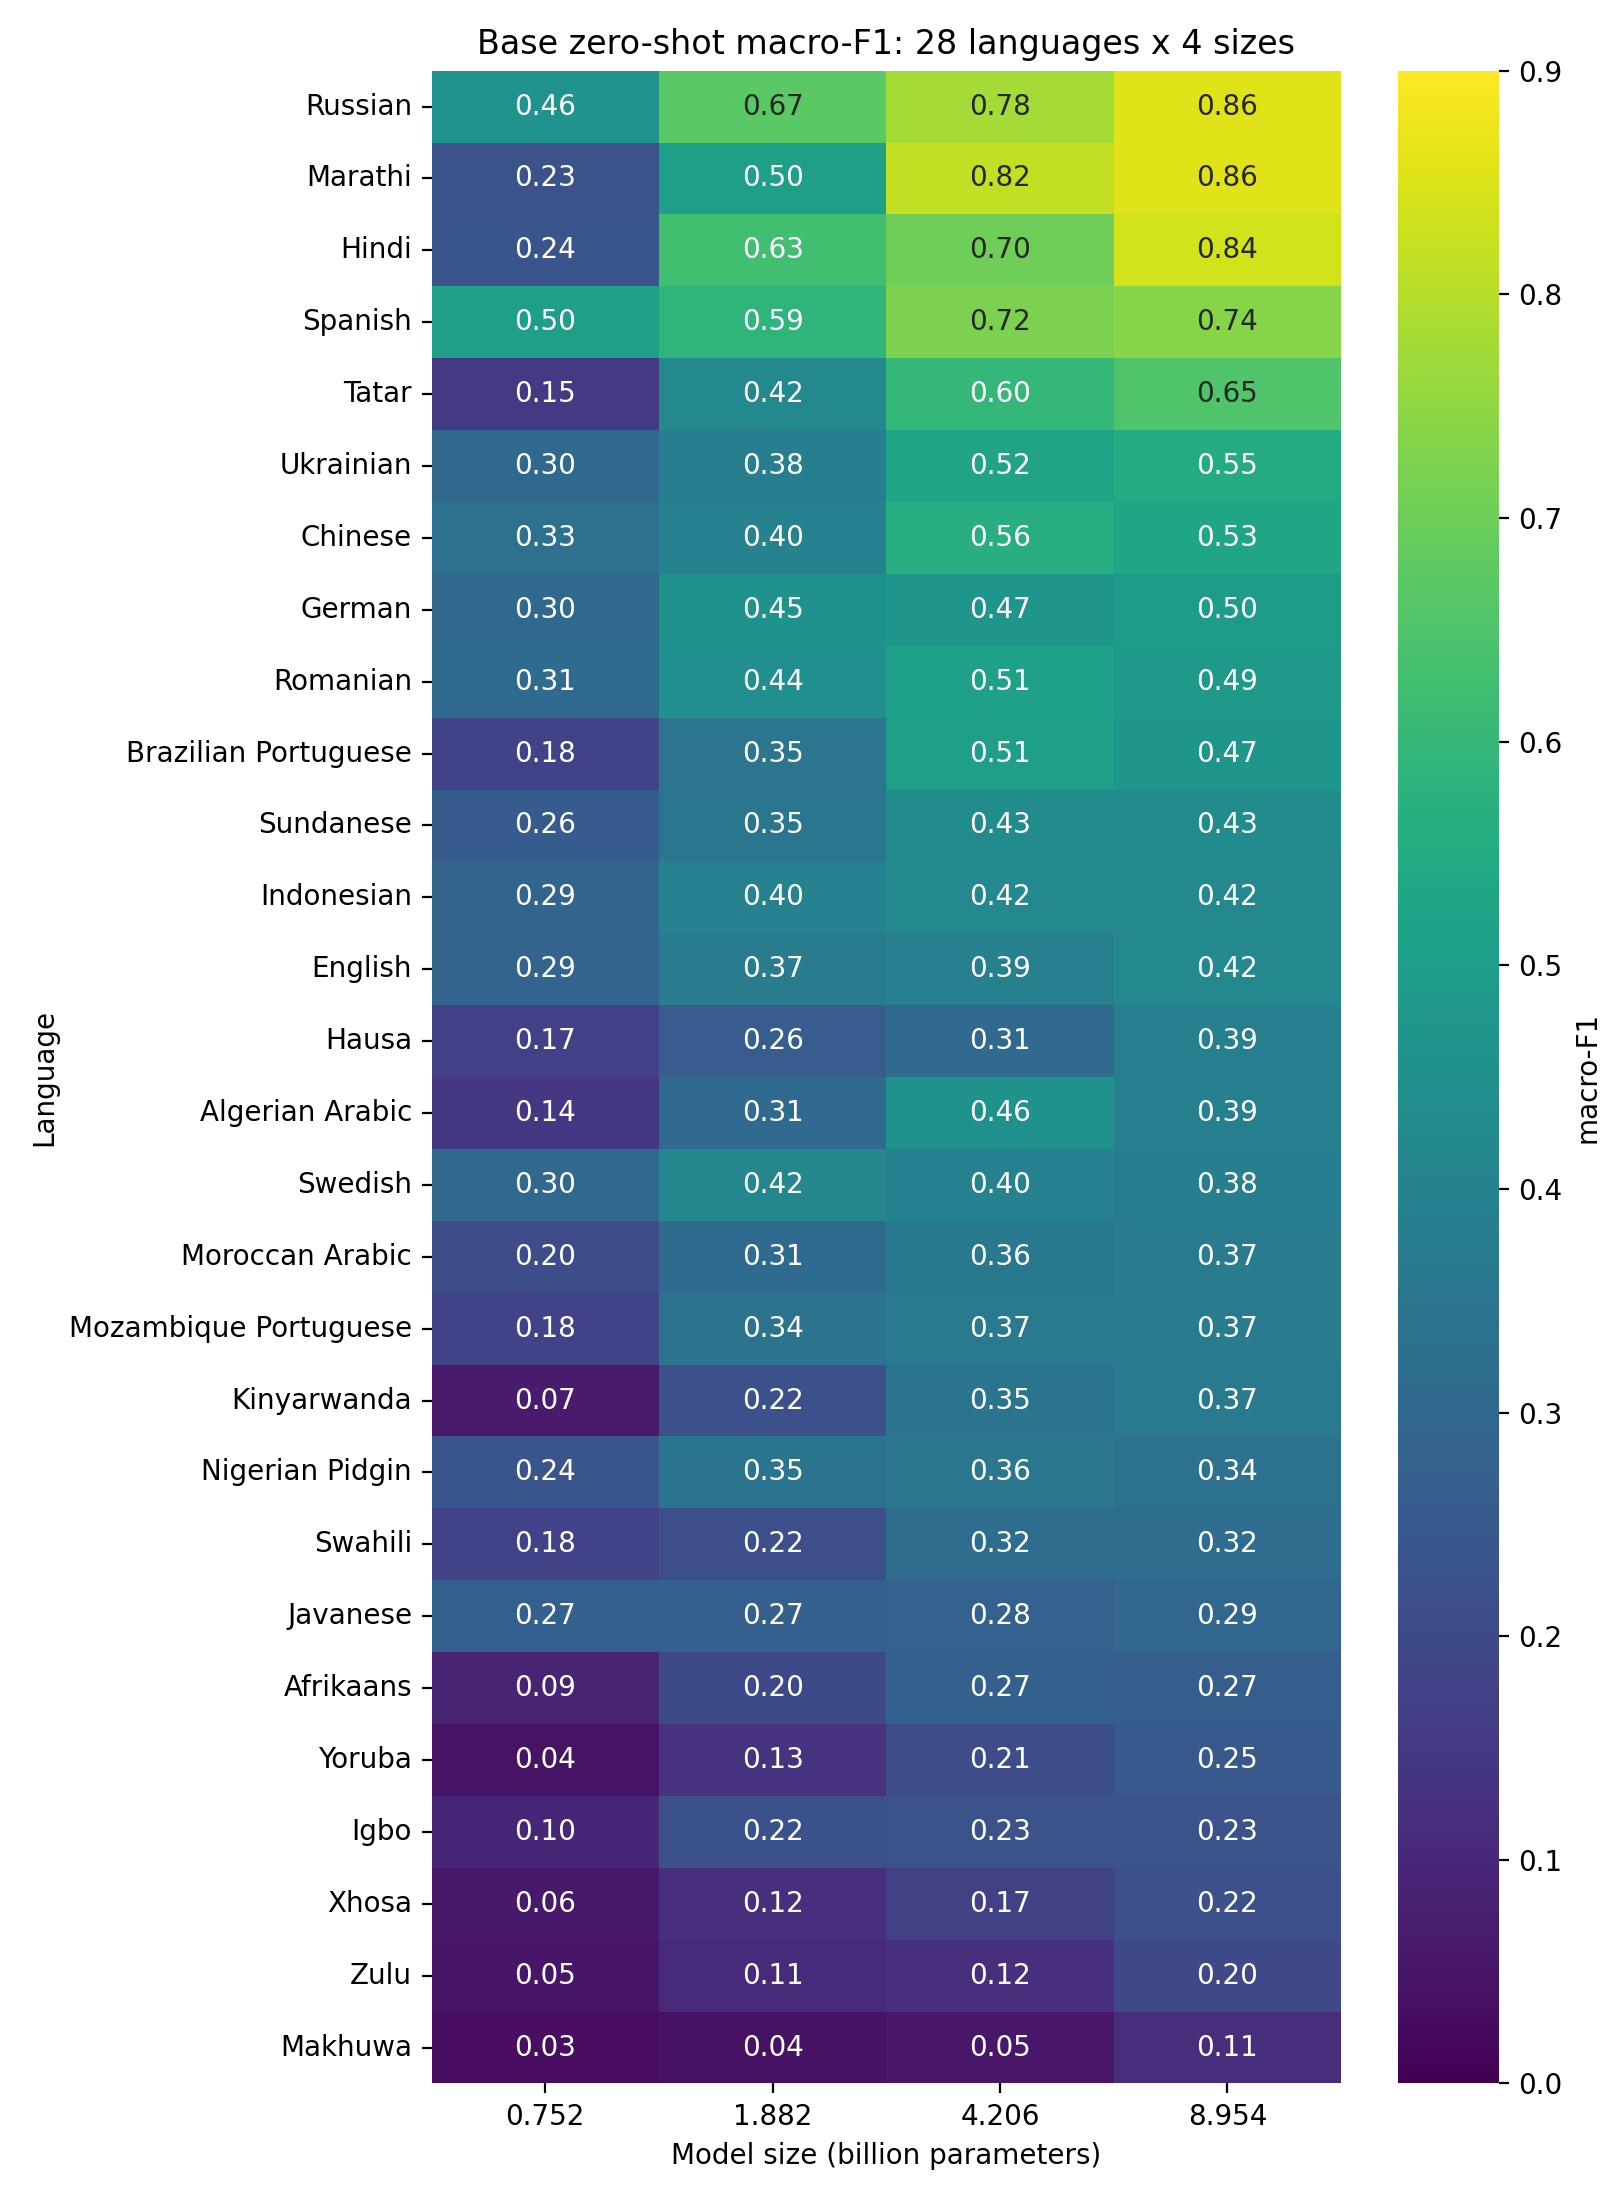

28-language mean macro-F1 by size:
params_billion
0.752    0.213
1.882    0.338
4.206    0.417
8.954    0.437


In [13]:
all_languages_base_frame = study_all_languages_base(base_config=studies_config)

if all_languages_base_frame is not None:
    heatmap_path = plot_language_size_heatmap(
        all_language_frame=all_languages_base_frame,
        config=studies_config,
    )
    show_figure(heatmap_path)
    size_mean = all_languages_base_frame.groupby("params_billion")["macro_f1"].mean()
    print("28-language mean macro-F1 by size:")
    print(size_mean.round(3).to_string())

## Step 8: Chinese Heritage Check

`chn` is the only CJK language in BRIGHTER, so it is our one test of whether Qwen's Chinese pretraining gives it an edge. We compare base vs. fine-tuned macro-F1 across model sizes.

At 0.8B, fine-tuning adds roughly +0.15 macro-F1 on Chinese (the base model is too small to handle the task reliably). By 4B the base model already performs reasonably on Chinese, and fine-tuning slightly hurts it - narrowing focus toward the training languages at the cost of cross-lingual transfer. For Chinese specifically, the 4B base is the better choice.

[chinese-base] loading cached result: /home/nik/code/github.com/MayNiklas/MMD2-project/reports/tables/qwen3.5_chinese_base_dev.csv


[chinese-finetune] loading cached result: /home/nik/code/github.com/MayNiklas/MMD2-project/reports/tables/qwen3.5_chinese_finetuned_dev.csv


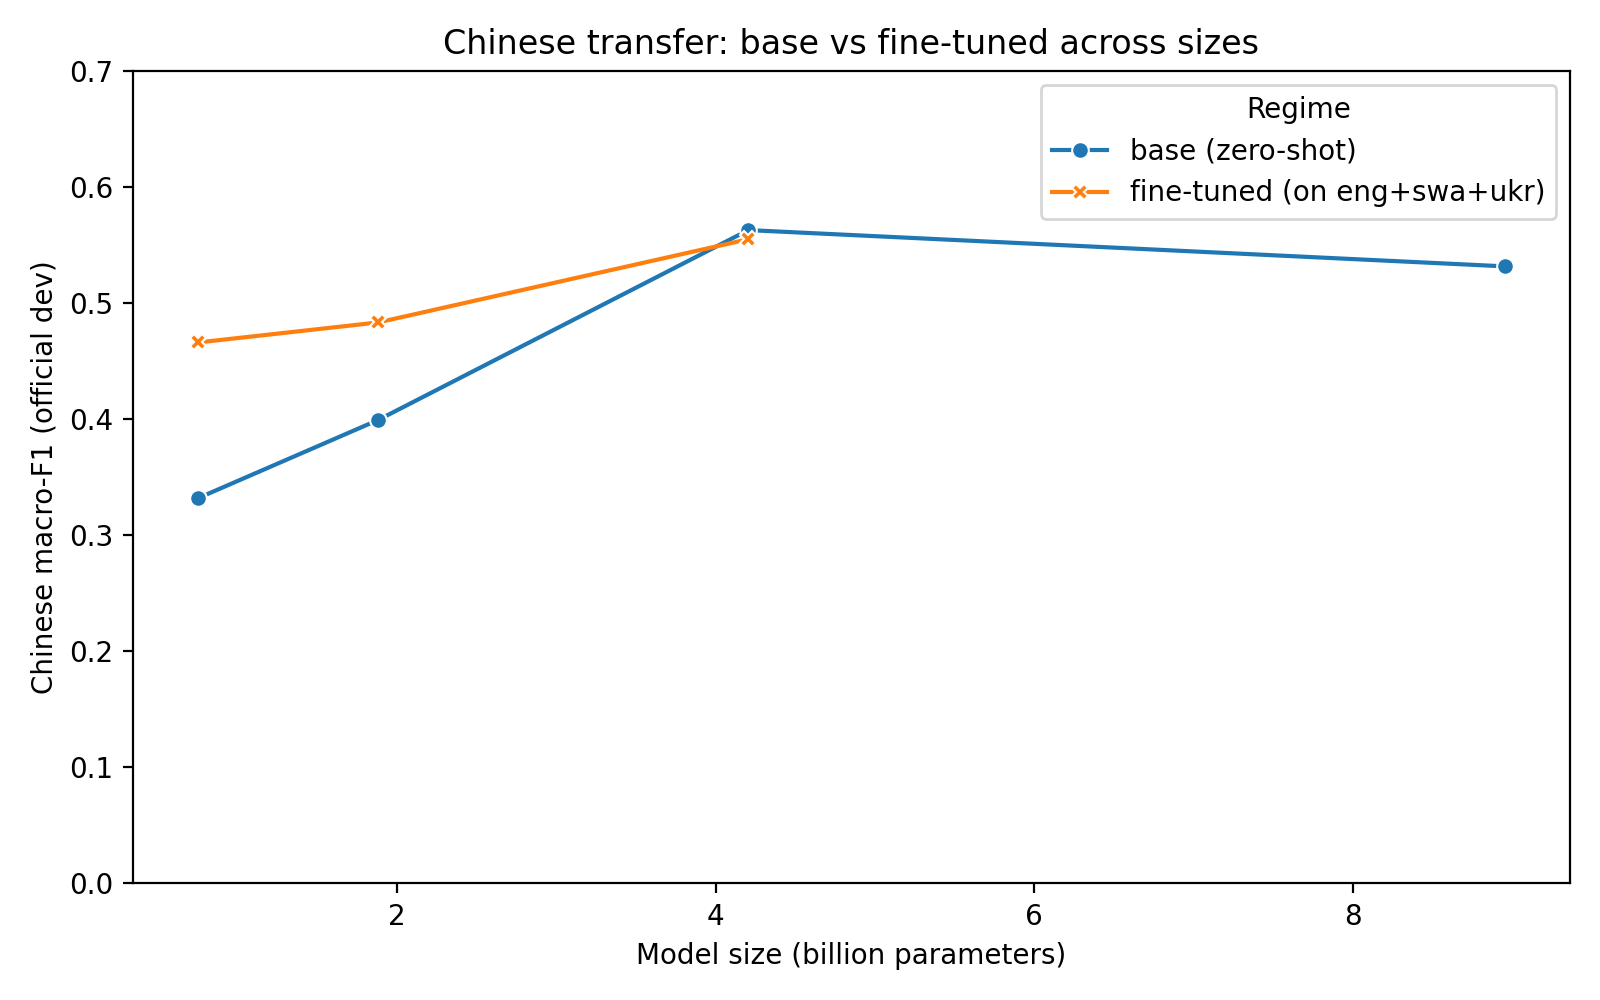

Chinese base (zero-shot) macro-F1 by size:
 params_billion  macro_f1
          0.752  0.331862
          1.882  0.399148
          4.206  0.562695
          8.954  0.531457

Chinese fine-tuned (FT on eng+swa+ukr) macro-F1 by size:
 params_billion  macro_f1
          0.752  0.465920
          1.882  0.483165
          4.206  0.554861


In [14]:
chinese_frames = study_chinese(base_config=studies_config)
chinese_base_frame = chinese_frames["base"]
chinese_finetuned_frame = chinese_frames["finetuned"]

if chinese_base_frame is not None:
    chinese_plot_path = plot_chinese_base_vs_finetuned(
        base_frame=chinese_base_frame,
        finetuned_frame=chinese_finetuned_frame,
        config=studies_config,
    )
    show_figure(chinese_plot_path)
    print("Chinese base (zero-shot) macro-F1 by size:")
    print(chinese_base_frame[["params_billion", "macro_f1"]].to_string(index=False))
    if chinese_finetuned_frame is not None:
        print("\nChinese fine-tuned (FT on eng+swa+ukr) macro-F1 by size:")
        print(chinese_finetuned_frame[["params_billion", "macro_f1"]].to_string(index=False))

## Step 9: Multi-Seed Noise Floor

We train the 0.8B recipe with 5 different seeds and track macro-F1 by epoch on the trained languages. The standard deviation at epoch 3 is about +-0.01 - single-seed differences smaller than that are not reliable.

[multiseed] loading cached result: /home/nik/code/github.com/MayNiklas/MMD2-project/reports/tables/qwen3.5-0.8B_multiseed_macro_f1_bands.csv


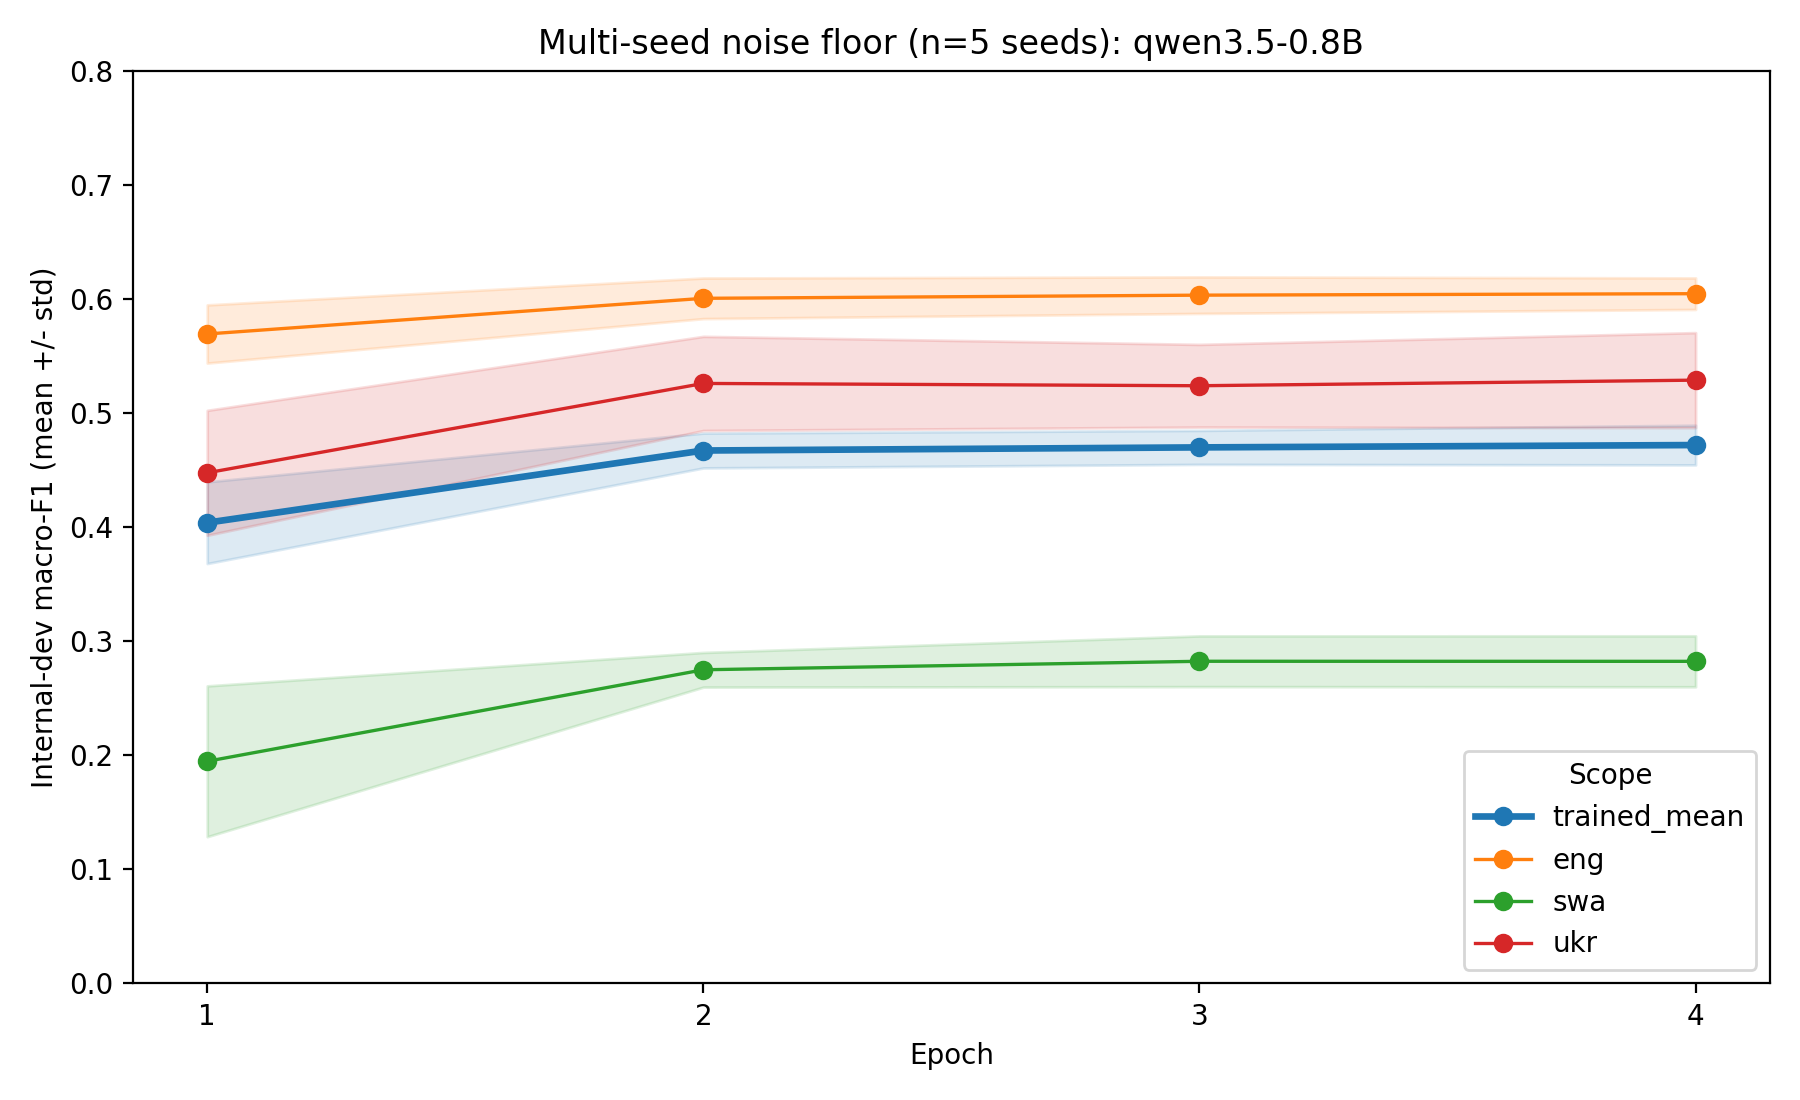

Trained-language mean macro-F1 +/- std by epoch (the noise floor):
 epoch  macro_f1_mean  macro_f1_std  n_seeds
     1       0.403825      0.035786        5
     2       0.467090      0.015264        5
     3       0.469822      0.014888        5
     4       0.471867      0.017396        5


In [15]:
multiseed_bands_frame = study_multiseed(base_config=studies_config)

if multiseed_bands_frame is not None:
    multiseed_plot_path = plot_multiseed_bands(
        bands_frame=multiseed_bands_frame,
        config=studies_config,
    )
    show_figure(multiseed_plot_path)
    trained_mean_bands = multiseed_bands_frame[multiseed_bands_frame["scope"] == "trained_mean"]
    print("Trained-language mean macro-F1 +/- std by epoch (the noise floor):")
    print(trained_mean_bands[["epoch", "macro_f1_mean", "macro_f1_std", "n_seeds"]].to_string(index=False))

## Step 10: What We Tried That Didn't Work

To keep the report honest, we document what we explored and ruled out:

- **Hyperparameter tuning** - we swept learning rate, epoch count, and weight decay on internal dev. All roads led to lr=1e-5, 3 epochs, wd=0.01. Going from 2 to 3 epochs and switching to cosine+warmup helped; everything else was within the noise floor.
- **Rare-emotion oversampling** - upsampling underrepresented emotions (e.g. Swahili `fear`) consistently hurt overall macro-F1. The model overfit the rare class without recovering the others.
- **Rich system prompt** - adding per-emotion cue descriptions to the prompt made no meaningful difference (within +-0.01), so we kept the minimal prompt.
- **Few-shot in-context examples** - the SFT model was trained on the zero-shot prompt format, so prepending labeled examples at inference risks a format mismatch. We didn't pursue it.

Two things we didn't have time for but seem worth trying: LoRA (might preserve zero-shot transfer while keeping the trained-language gains, and would make 9B fine-tuning feasible on 24 GB) and back-translation data augmentation for the weakest cells.

## Step 11: LIME Error Analysis

We use LIME to probe where the model goes wrong. Since the model generates labels rather than outputting logits, we convert generated labels into proxy probabilities for LIME. These explanations are qualitative - useful for spotting patterns, not for precise attribution scores.

In [1]:
lime_example_count: int = 1 if RUN_MODE == "smoke" else 6
lime_examples_frame: pd.DataFrame = select_lime_examples(
    predictions_frame=predictions_frame,
    max_examples=lime_example_count,
)
lime_paths: list[Path] = explain_lime_examples(
    model=trainer.model,
    tokenizer=tokenizer,
    examples_frame=lime_examples_frame,
    config=config,
)

for html_path in lime_paths:
    png_path = html_path.with_suffix(".png")
    if png_path.exists():
        show_figure(png_path)

lime_paths

NameError: name 'RUN_MODE' is not defined

## Step 12: Summary

In [17]:
summary_path: Path = write_markdown_summary(
    metrics_frame=metrics_frame,
    per_label_metrics_frame=per_label_metrics_frame,
    lime_paths=lime_paths,
    config=config,
)
summary_path

PosixPath('/home/nik/code/github.com/MayNiklas/MMD2-project/reports/qwen3.5-0.8B_results_summary.md')